In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv(r'C:\Users\wwwww\Desktop\superstore dataset\cleaned\sales_cleaned.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.describe()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales'],
      dtype='str')

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

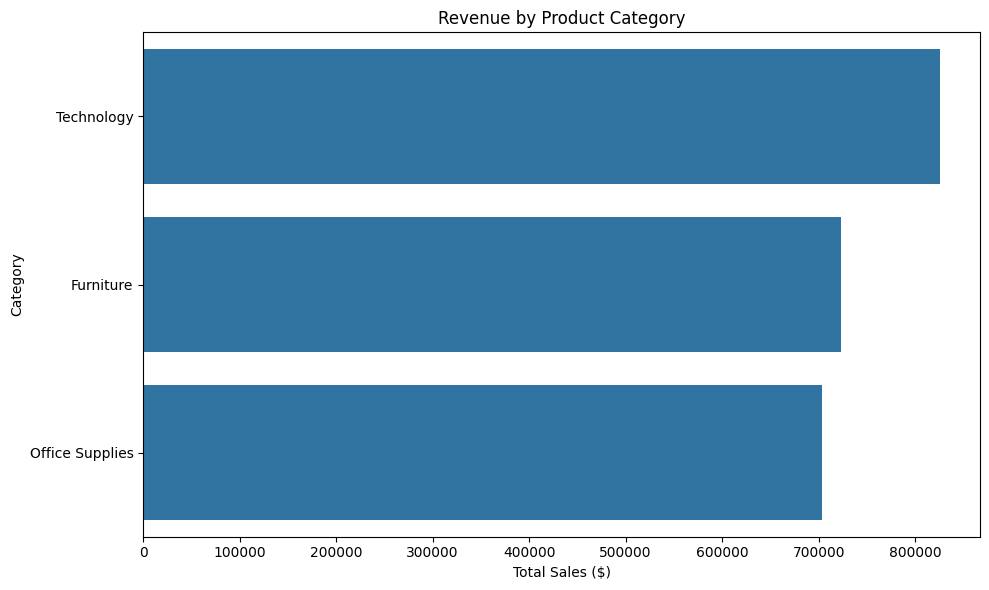

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Revenue by Product Category")
plt.xlabel("Total Sales ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [8]:
#**Insight 1:**
#The Technology category generates the highest revenue, followed by Furniture and Office Supplies.
#This suggests the business should prioritize Technology products for higher returns.

In [9]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

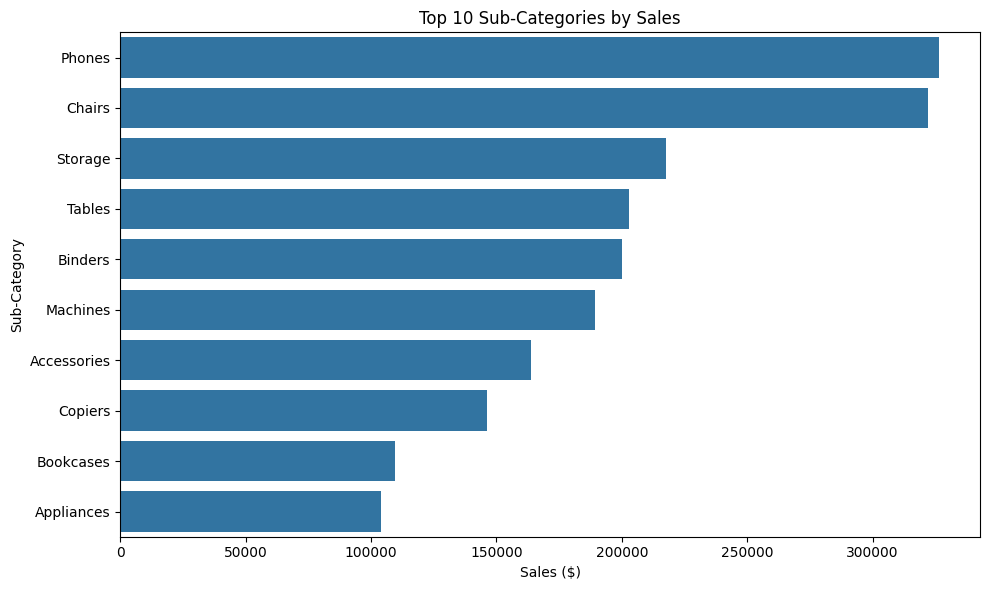

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index)
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [11]:
#**Insight 2:**
#Sub-categories such as Phones and Chairs dominate sales.
#Focusing marketing and inventory on these high-performing products can increase revenue.

In [12]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

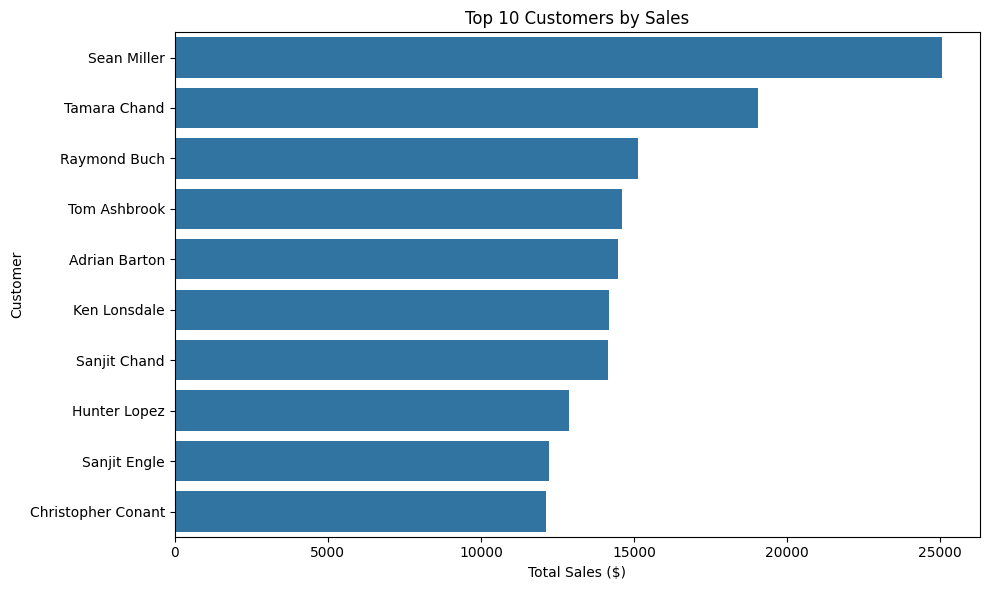

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

In [14]:
#**Insight 3:**
#A small group of customers contributes a large portion of total revenue.
#This suggests the business should focus on retaining high-value customers through loyalty programs or personalized offers.

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()



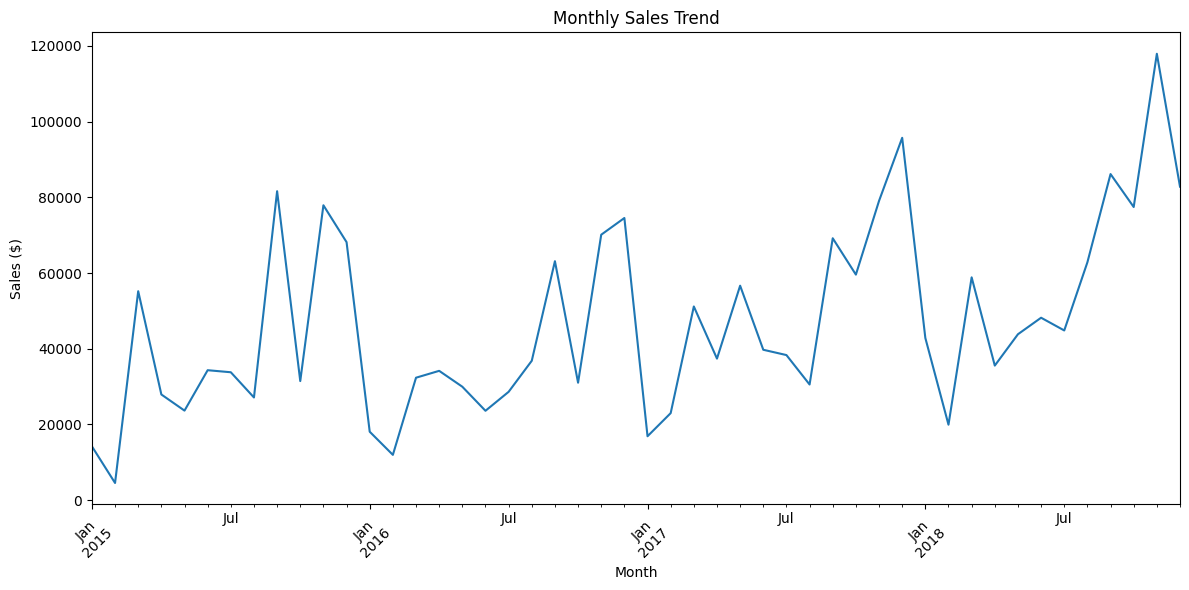

In [17]:
monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
#**Insight 4:**
#Sales show clear peaks during certain months, indicating seasonal demand patterns.
#The business can optimize marketing campaigns and inventory planning during high-demand periods.